In [20]:
from project.utilities.simulation import run_trials, run_task, TrialParams, run_experiments, DotsParams, get_CI
from project.utilities.statistics import bootstrap_ci, bootstrap_difference_ci
from project.utilities.io import load_results, save_plot, use_latex_fonts, figure_size

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np
from numpy.random import default_rng
from dataclasses import asdict, replace
from scipy.stats import bootstrap
from statsmodels.stats.proportion import proportion_confint

from pathlib import Path
import pandas as pd

from project.networks.cbgt import ModelParams, ThalamusParams, BGParams, CBGT
from project.networks.cortex import CortexParams

# For displaying
from IPython.display import display, HTML

# Change font of plots
use_latex_fonts()

# Import data

Importing the data generated in `scripts\cortical dynamics\suite2.ipynb`

### Summary Statistics

In [21]:
summary_stats = load_results('suite2_summary.csv', '../../data/cortical dynamics') 
summary_stats_bypass = load_results('suite2_bypass_summary.csv', '../../data/cortical dynamics')


Loaded: ..\..\data\cortical dynamics\suite2_summary.csv
Loaded: ..\..\data\cortical dynamics\suite2_bypass_summary.csv


In [22]:
display(HTML("<h1 style='font-size:25px'>Summary statistics with cortex</h1>"))
summary_stats.head(5)

,coherence,strength,Accuracy (%),Accuracy Difference (%),Accuracy CI Low (%),Accuracy CI High (%),Accuracy Diff CI Low (%),Accuracy Diff CI High (%),Mean Correct RT (ms),Mean Correct RT CI Margin (ms),...,Correct RT std CI High (ms),Inverse Efficiency,Correct Decision (%),Wrong Decision (%),No Decision (%),Premature (%),Wrong Decision CI Low (%),Wrong Decision CI High (%),Mean PD Variability,Mean PD Variability CI Margin
exp_id,,,,,,,,,,,,,,,,,,,,,
0,1.0,0.8,100.0,0.0,96.3,100.0,-7.13,7.13,51.61,0.17,...,0.95,51.61,100.0,0.0,0.0,0.0,0.0,3.7,0.032,0.000
1,1.0,0.6,100.0,0.0,96.3,100.0,-7.13,7.13,55.45,0.22,...,1.30,55.45,100.0,0.0,0.0,0.0,0.0,3.7,0.033,0.000
2,1.0,0.4,100.0,0.0,96.3,100.0,-7.13,7.13,64.89,0.74,...,3.92,64.89,100.0,0.0,0.0,0.0,0.0,3.7,0.039,0.001
3,0.3,0.8,100.0,0.0,96.3,100.0,-7.13,7.13,67.37,0.59,...,3.35,67.37,100.0,0.0,0.0,0.0,0.0,3.7,0.035,0.000
4,0.3,0.6,100.0,0.0,96.3,100.0,-7.13,7.13,77.33,0.92,...,5.15,77.33,100.0,0.0,0.0,0.0,0.0,3.7,0.040,0.001


In [23]:
display(HTML("<h1 style='font-size:25px'>Summary statistics bypassing cortex</h1>"))
summary_stats_bypass.head(5)

,coherence,strength,Accuracy (%),Accuracy Difference (%),Accuracy CI Low (%),Accuracy CI High (%),Accuracy Diff CI Low (%),Accuracy Diff CI High (%),Mean Correct RT (ms),Mean Correct RT CI Margin (ms),...,Correct RT std CI High (ms),Inverse Efficiency,Correct Decision (%),Wrong Decision (%),No Decision (%),Premature (%),Wrong Decision CI Low (%),Wrong Decision CI High (%),Mean PD Variability,Mean PD Variability CI Margin
exp_id,,,,,,,,,,,,,,,,,,,,,
0,1.0,0.8,100.0,0.0,96.30,100.00,-7.13,7.13,36.12,0.21,...,1.12,36.12,100.0,0.0,0.0,0.0,0.0,3.7,0.032,0.000
1,1.0,0.6,100.0,0.0,96.30,100.00,-7.13,7.13,35.97,0.22,...,1.21,35.97,100.0,0.0,0.0,0.0,0.0,3.7,0.032,0.000
2,1.0,0.4,100.0,0.0,96.30,100.00,-7.13,7.13,38.67,0.47,...,2.94,38.67,100.0,0.0,0.0,0.0,0.0,3.7,0.042,0.001
3,0.3,0.8,100.0,0.0,96.30,100.00,-7.13,7.13,58.75,2.10,...,13.52,58.75,100.0,0.0,0.0,0.0,0.0,3.7,0.061,0.002
4,0.3,0.6,80.0,-28.0,71.12,86.66,-42.40,-12.57,321.25,47.81,...,242.68,401.56,80.0,0.0,20.0,0.0,0.0,3.7,0.093,0.003


The model paramaters are carefully designed not to give rise to any premature decision. For completeness, this can quickly be verified.

In [24]:
print('Amount of premature decision with cortex:', summary_stats['Premature (%)'].sum())
print('Amount of premature decision without cortex:', summary_stats_bypass['Premature (%)'].sum())

Amount of premature decision with cortex: 0.0
Amount of premature decision without cortex: 0.0


As expected, no premature decisions.

### Trial data

Importing trial data

In [25]:
# Index by trial_id
trial_data = load_results('suite2_trials.csv', '../../data/cortical dynamics', index_col = 'trial_id') 
trial_data_bypass = load_results('suite2_bypass_trials.csv', '../../data/cortical dynamics', index_col = 'trial_id')


Loaded: ..\..\data\cortical dynamics\suite2_trials.csv
Loaded: ..\..\data\cortical dynamics\suite2_bypass_trials.csv


In [26]:
display(HTML("<h1 style='font-size:25px'>Trial data with cortex</h1>"))
trial_data.head(5)


,exp_id,stim_info.direction,stim_info.coherence,stim_info.strength,stim_info.noise_std,stim_info.tau,decision_info.Decision,decision_info.Accurate,decision_info.RT (ms),decision_info.Outcome,decision_info.PD Variability,trial_info.model_seed,trial_info.master_seed,trial_info.decision_threshold,trial_info.max_time (s)
trial_id,,,,,,,,,,,,,,,
0,0,1,1.0,0.8,0.125,0.01,1.0,True,52.0,Correct Decision,0.031406,1,1,0.7,1
1,0,0,1.0,0.8,0.125,0.01,0.0,True,52.0,Correct Decision,0.032963,1,1,0.7,1
2,0,1,1.0,0.8,0.125,0.01,1.0,True,52.0,Correct Decision,0.031202,1,1,0.7,1
3,0,0,1.0,0.8,0.125,0.01,0.0,True,52.0,Correct Decision,0.032667,1,1,0.7,1
4,0,1,1.0,0.8,0.125,0.01,1.0,True,51.0,Correct Decision,0.031855,1,1,0.7,1


In [27]:
display(HTML("<h1 style='font-size:25px'>Trial data bypassing cortex</h1>"))
trial_data_bypass.head(5)

,exp_id,stim_info.direction,stim_info.coherence,stim_info.strength,stim_info.noise_std,stim_info.tau,decision_info.Decision,decision_info.Accurate,decision_info.RT (ms),decision_info.Outcome,decision_info.PD Variability,trial_info.model_seed,trial_info.master_seed,trial_info.decision_threshold,trial_info.max_time (s)
trial_id,,,,,,,,,,,,,,,
0,0,1,1.0,0.8,0.125,0.01,1.0,True,35.0,Correct Decision,0.032241,1,1,0.7,1
1,0,0,1.0,0.8,0.125,0.01,0.0,True,37.0,Correct Decision,0.032906,1,1,0.7,1
2,0,1,1.0,0.8,0.125,0.01,1.0,True,35.0,Correct Decision,0.032247,1,1,0.7,1
3,0,0,1.0,0.8,0.125,0.01,0.0,True,37.0,Correct Decision,0.032689,1,1,0.7,1
4,0,1,1.0,0.8,0.125,0.01,1.0,True,36.0,Correct Decision,0.031093,1,1,0.7,1


# Plotting Data

Splitting data by strength level

In [28]:
# ===== Split data by strength level =====
# - With cortex -
# Summary stats
df_08 = summary_stats[summary_stats['strength'] == 0.8]
df_06 = summary_stats[summary_stats['strength'] == 0.6]
df_04 = summary_stats[summary_stats['strength'] == 0.4]
# Trial data
trial_08 = trial_data[trial_data['stim_info.strength'] == 0.8]
trial_06 = trial_data[trial_data['stim_info.strength'] == 0.6]
trial_04 = trial_data[trial_data['stim_info.strength'] == 0.4]

# -Bypass cortex-
# Summary Stats
df_08_bypass = summary_stats_bypass[summary_stats_bypass['strength'] == 0.8]
df_06_bypass = summary_stats_bypass[summary_stats_bypass['strength'] == 0.6]
df_04_bypass = summary_stats_bypass[summary_stats_bypass['strength'] == 0.4]
# Trial data
trial_08_bypass = trial_data_bypass[trial_data_bypass['stim_info.strength'] == 0.8]
trial_06_bypass = trial_data_bypass[trial_data_bypass['stim_info.strength'] == 0.6]
trial_04_bypass = trial_data_bypass[trial_data_bypass['stim_info.strength'] == 0.4]

Plotting relevant summary statistics

### Accuracy and mistakes vs coherence

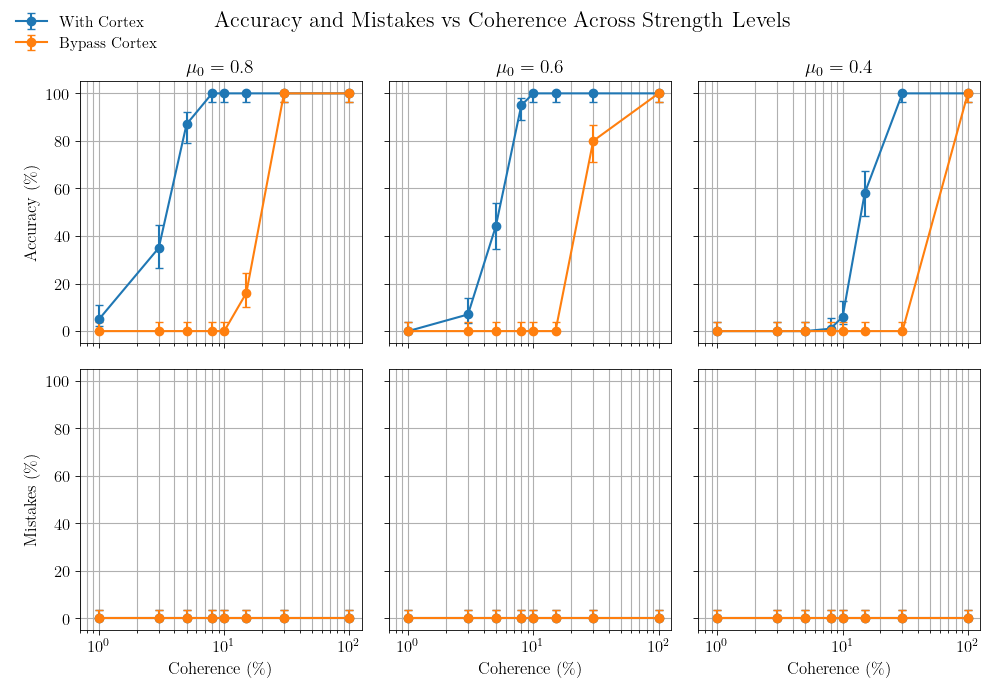

Saved: ..\..\figures\cortical dynamics\suite2\Accuracy and Mistakes vs Coherence.pdf
Saved: ..\..\figures\cortical dynamics\suite2\Accuracy and Mistakes vs Coherence.png


In [29]:
# ==== Get mean and confidence intervals for each strengthbm level ====
# --- Accuracy ---
acc_08, acc_err_08 = get_CI(df_08, metric='Accuracy (%)') 
acc_06, acc_err_06 = get_CI(df_06, metric='Accuracy (%)') 
acc_04, acc_err_04 = get_CI(df_04, metric='Accuracy (%)') 

acc_08_bypass, acc_err_08_bypass = get_CI(df_08_bypass, metric='Accuracy (%)') 
acc_06_bypass, acc_err_06_bypass = get_CI(df_06_bypass, metric='Accuracy (%)') 
acc_04_bypass, acc_err_04_bypass = get_CI(df_04_bypass, metric='Accuracy (%)') 

# --- Mistakes ---
mistakes_08, mistakes_err_08 = get_CI(df_08, metric='Wrong Decision (%)')
mistakes_06, mistakes_err_06 = get_CI(df_06, metric='Wrong Decision (%)')
mistakes_04, mistakes_err_04 = get_CI(df_04, metric='Wrong Decision (%)')

mistakes_08_bypass, mistakes_err_08_bypass = get_CI(df_08_bypass, metric='Wrong Decision (%)')
mistakes_06_bypass, mistakes_err_06_bypass = get_CI(df_06_bypass, metric='Wrong Decision (%)')
mistakes_04_bypass, mistakes_err_04_bypass = get_CI(df_04_bypass, metric='Wrong Decision (%)')

# ==== Plotting ====
coherences = summary_stats['coherence'].unique()*100
fig, ax = plt.subplots(2,  3,  figsize= (figure_size('double')), subplot_kw={"xscale": "log"}, sharex = True, sharey = 'row')


# Accuracy
ax[0,0].errorbar(x = coherences, y = acc_08, yerr = acc_err_08, fmt='o-', capsize = 3, markersize = 6, label='With Cortex')
ax[0,0].errorbar(x = coherences, y = acc_08_bypass, yerr = acc_err_08_bypass, fmt='o-', capsize = 3, markersize = 6, label='Bypass Cortex')
ax[0,0].set_title('$\mu_0 = 0.8$')
ax[0,0].set_ylabel('Accuracy (\%)')
ax[0,0].grid(which = 'both')

ax[0,1].errorbar(x = coherences, y = acc_06, yerr = acc_err_06, fmt='o-', capsize = 3, markersize = 6)
ax[0,1].errorbar(x = coherences, y = acc_06_bypass, yerr = acc_err_06_bypass, fmt='o-', capsize = 3, markersize = 6)
ax[0,1].set_title('$\mu_0 = 0.6$')
ax[0,1].grid(which = 'both')

ax[0,2].errorbar(x = coherences, y = acc_04, yerr = acc_err_04, fmt='o-', capsize = 3, markersize = 6)
ax[0,2].errorbar(x = coherences, y = acc_04_bypass, yerr = acc_err_04_bypass, fmt='o-', capsize = 3, markersize = 6)
ax[0,2].set_title('$\mu_0 = 0.4$')
ax[0,2].grid(which = 'both')
 

# Mistakes
ax[1, 0].errorbar(x = coherences, y = mistakes_08, yerr = mistakes_err_08, fmt='o-', capsize = 3, markersize = 6)
ax[1, 0].errorbar(x = coherences, y = mistakes_08_bypass, yerr = mistakes_err_08_bypass, fmt='o-', capsize = 3, markersize = 6)
ax[1, 0].set_xlabel('Coherence (\%)')
ax[1, 0].set_ylabel('Mistakes (\%)')
ax[1, 0].grid(which = 'both')

ax[1, 1].errorbar(x = coherences, y = mistakes_06, yerr = mistakes_err_06, fmt='o-', capsize = 3, markersize = 6)
ax[1, 1].errorbar(x = coherences, y = mistakes_06_bypass, yerr = mistakes_err_06_bypass, fmt='o-', capsize = 3, markersize = 6)
ax[1, 1].set_xlabel('Coherence (\%)')
ax[1, 1].grid(which = 'both')

ax[1, 2].errorbar(x = coherences, y = mistakes_04, yerr = mistakes_err_04, fmt='o-', capsize = 3, markersize = 6)
ax[1, 2].errorbar(x = coherences, y = mistakes_04_bypass, yerr = mistakes_err_04_bypass, fmt='o-', capsize = 3, markersize = 6)
ax[1, 2].set_xlabel('Coherence (\%)')
ax[1, 2].grid(which = 'both')

ax[1, 2].set_xlim(left = 0.7)
ax[1, 2].set_ylim(-5, 105)

fig.legend(loc="center left", bbox_to_anchor=(0.0, 0.95), frameon=False)
plt.suptitle('Accuracy and Mistakes vs Coherence Across Strength Levels')
plt.tight_layout()
plt.show()

# Save plot
save_plot(fig, 'Accuracy and Mistakes vs Coherence', folder='../../figures/cortical dynamics/suite2', formats=('pdf', 'png'))

Cortical processing appears to have a particularly prominent effect on accuracy as the strength drops. To gain more insight into this, two additional trials are run at low strength level: one with and one without the cortex

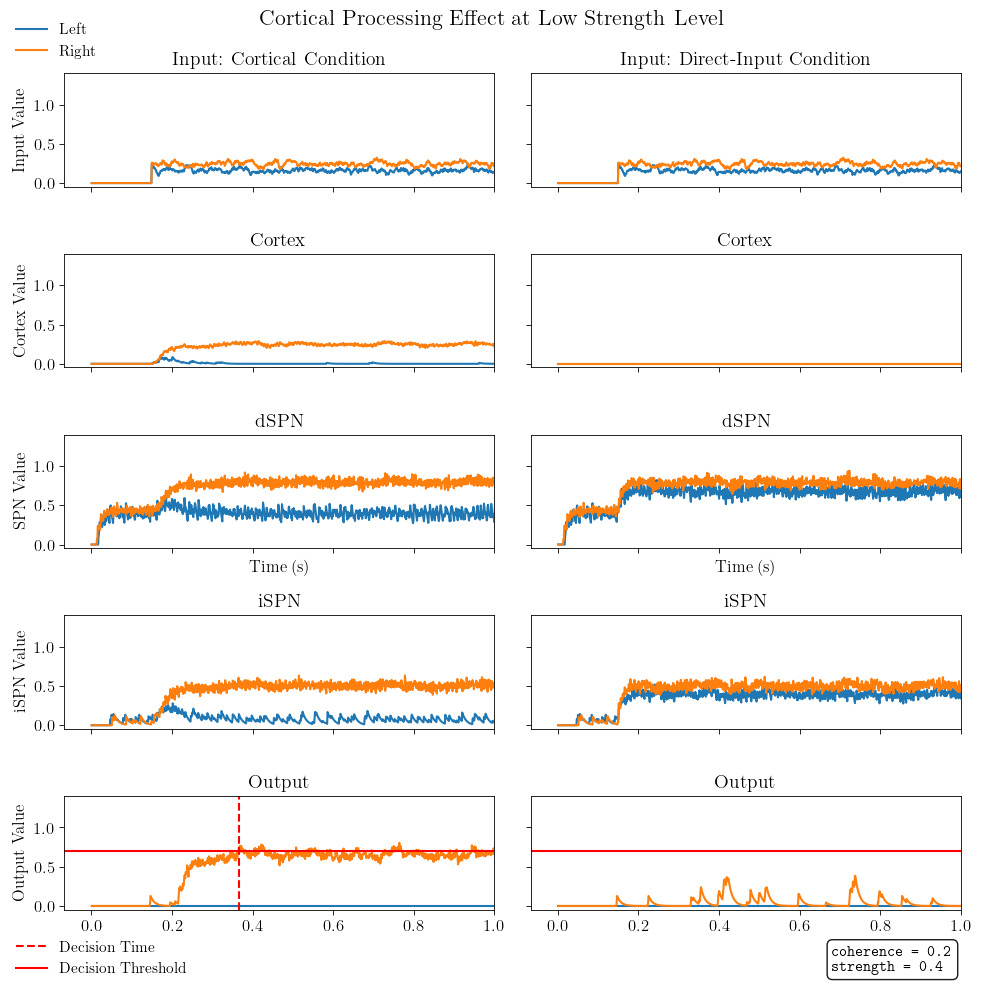

Saved: ..\..\figures\cortical dynamics\suite2\Cortical Processing Effect at Low Strength.pdf
Saved: ..\..\figures\cortical dynamics\suite2\Cortical Processing Effect at Low Strength.png


In [30]:
# ---- Parameters -----
task_seed = 2
t_warmup = 0.15 # Relevant when computing decision time
decision_threshold = 0.7
strength = 0.4
coherence = 0.20

bg_params = BGParams()
thal_params = ThalamusParams()
cx_params = CortexParams()
model_parameters = ModelParams(
    bg_params = bg_params, 
    th_params = thal_params, 
    cx_params = cx_params
    )
trial_params = TrialParams(
    model_seed = 1, 
    task_seed = task_seed, 
    t_warmup = t_warmup, 
    decision_threshold = decision_threshold,
    decision_window= 5e-3,
    PD_window = 1,
    max_time = 1
    )
task_params = DotsParams(
    direction = 'right', 
    strength = strength,
    coherence = coherence,
    noise_std = 0.125
    )


# ---- Run decision-making task ----

# Cortical condition
task_result = run_task(
    model_params = model_parameters,
    dots_params = task_params,
    trial_params = trial_params,
    return_probes = True,

)
# Direct-Input Condition
task_result_bypass = run_task(
    model_params = model_parameters,
    dots_params = task_params,
    trial_params = trial_params,
    return_probes = True,
    bypass_cortex = True
)

# ---- Get decision time for cortical condition ----
decision_time = task_result.decision_info['RT (ms)']/1000 + t_warmup

# ---- Extract relevant probe data ----
probes = task_result.probes
probes_bypass = task_result_bypass.probes

# Time
time = probes['time']
time_bypass = probes_bypass['time']

# Input probes
input_probe = probes['input']
input_probe_bypass = probes_bypass['input']

# Cortex probes
cortex_probe = probes['cortex']
cortex_probe_bypass = probes_bypass['cortex']

# SPN probes
dSPN_probe = probes['dSPN']
iSPN_probe = probes['iSPN']
dSPN_probe_bypass = probes_bypass['dSPN']
iSPN_probe_bypass = probes_bypass['iSPN']

# Output probes
output_probe_bypass = probes_bypass['output']
output_probe = probes['output']


# ---- Plot ----
fig, ax = plt.subplots(5, 2, figsize=figure_size('triple'), sharex = True, sharey = True)

# With cortex
Left, = ax[0,0].plot(time, input_probe[:,0], label = 'Left')
Right, = ax[0,0].plot(time, input_probe[:,1], label = 'Right')
ax[0,0].set_title('Input: Cortical Condition')

ax[1,0].plot(time, cortex_probe[:,0])
ax[1,0].plot(time, cortex_probe[:,1])
ax[1,0].set_title('Cortex')

ax[2,0].plot(time, dSPN_probe[:,0])
ax[2,0].plot(time, dSPN_probe[:,1])
ax[2,0].set_title('dSPN')

ax[3,0].plot(time, iSPN_probe[:,0])
ax[3,0].plot(time, iSPN_probe[:,1])
ax[3,0].set_title('iSPN')

ax[4,0].plot(time, output_probe[:,0])
ax[4,0].plot(time, output_probe[:,1])
ax[4,0].axhline(decision_threshold, color='r', linestyle='-')
ax[4,0].set_title('Output')

# Bypass cortex
ax[0,1].plot(time_bypass, input_probe[:,0][:1000])
ax[0,1].plot(time_bypass, input_probe[:,1][:1000])
ax[0,1].set_title('Input: Direct-Input Condition')

ax[1,1].plot(time_bypass, cortex_probe_bypass[:,0])
ax[1,1].plot(time_bypass, cortex_probe_bypass[:,1])
ax[1,1].set_title('Cortex')

ax[2,1].plot(time_bypass, dSPN_probe_bypass[:,0])
ax[2,1].plot(time_bypass, dSPN_probe_bypass[:,1])
ax[2,1].set_title('dSPN')

ax[3,1].plot(time_bypass, iSPN_probe_bypass[:,0])
ax[3,1].plot(time_bypass, iSPN_probe_bypass[:,1])
ax[3,1].set_title('iSPN')

ax[4,1].plot(time_bypass, output_probe_bypass[:,0])
ax[4,1].plot(time_bypass, output_probe_bypass[:,1])
ax[4,1].set_title('Output')


# Set axes limits
ax[4,1].set_xlim(right = 1)
ax[2, 0].set_ylim(top = 1.4)

# - Set axes labels -
# x-axis
ax[2,0].set_xlabel('Time (s)')
ax[2,1].set_xlabel('Time (s)')
# y-axis
ax[0,0].set_ylabel('Input Value')
ax[1,0].set_ylabel('Cortex Value')
ax[2,0].set_ylabel('SPN Value')
ax[3,0].set_ylabel('iSPN Value')
ax[4,0].set_ylabel('Output Value')

# - Lines for decision time and threshold -
decision_line = ax[4,0].axvline(decision_time, color='r', linestyle='--', label='Decision Time')
threshold_line = ax[4,1].axhline(decision_threshold, color='r', linestyle='-', label='Decision Threshold')

#  - Make legends -
fig.legend(
    handles=[Left, Right],
    loc="upper left",
    bbox_to_anchor=(0.01, 0.98),
    frameon=False
)
fig.legend(
    handles=[decision_line, threshold_line],
    loc="lower left",
    bbox_to_anchor=(0.01, 0.0),
    frameon=False
)

# - Add text with task parameters -
params_text = (
    rf" \texttt{{coherence = {coherence}}}" "\n"
    rf" \texttt{{strength = {strength}}}"
)

fig.text(
    0.96, 0.045,
    params_text,
    ha="right",
    va="top",
    usetex = True,
    fontfamily = "serif",
    fontname = "Computer Modern Roman",
    size=plt.rcParams["legend.fontsize"],
    multialignment="left",
    bbox=dict(
        boxstyle="round,pad=0.35",
        facecolor="white",
        edgecolor="0.1",
        alpha=1
    )
)

plt.suptitle('Cortical Processing Effect at Low Strength Level')
plt.tight_layout()
plt.subplots_adjust(bottom=0.08)
plt.show()

save_plot(fig, 'Cortical Processing Effect at Low Strength', folder='../../figures/cortical dynamics/suite2', formats=('pdf', 'png'))

Running the same task as above, but for default strength level

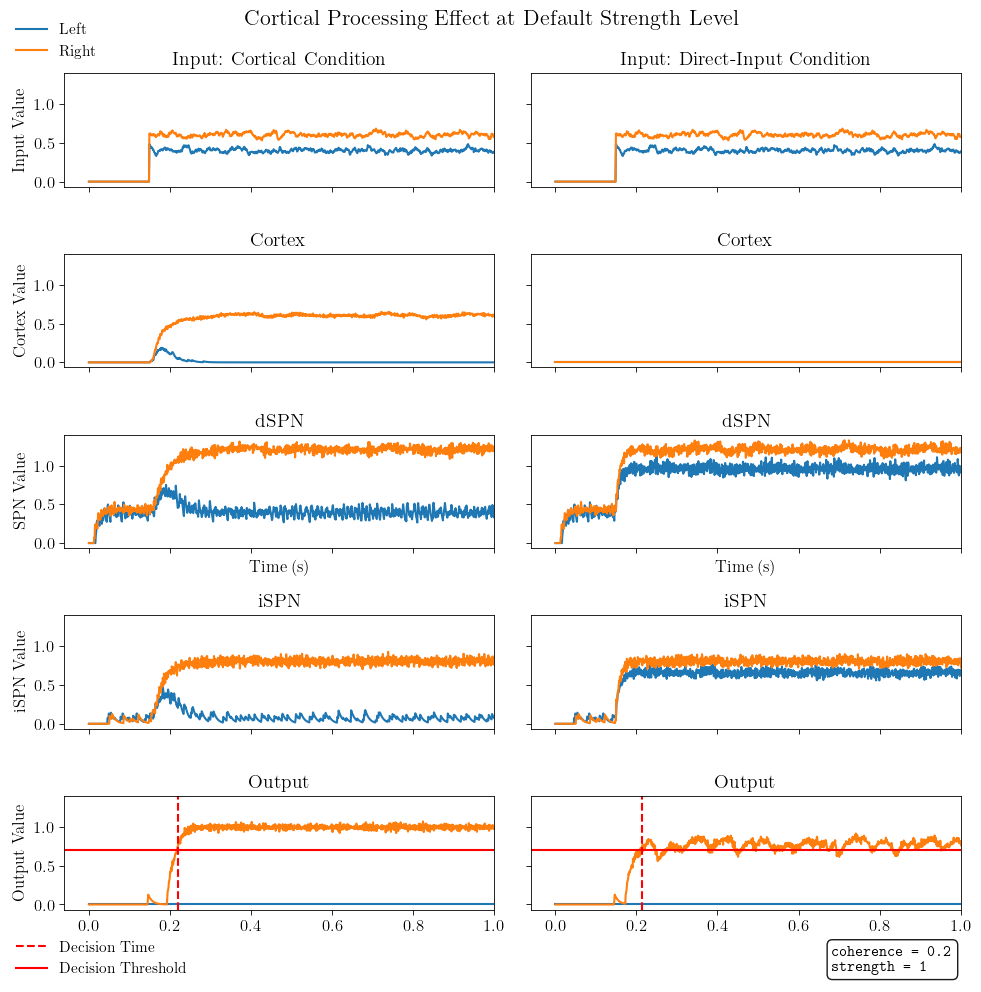

Saved: ..\..\figures\cortical dynamics\suite2\Cortical Processing Effect at Default Strength.pdf
Saved: ..\..\figures\cortical dynamics\suite2\Cortical Processing Effect at Default Strength.png


In [31]:
# ---- Parameters -----
task_seed = 2
t_warmup = 0.15 # Relevant when computing decision time
decision_threshold = 0.7
coherence = 0.20
strength = 1

bg_params = BGParams()
thal_params = ThalamusParams()
cx_params = CortexParams()
model_parameters = ModelParams(
    bg_params = bg_params, 
    th_params = thal_params, 
    cx_params = cx_params
    )
trial_params = TrialParams(
    model_seed = 1, 
    task_seed = task_seed, 
    t_warmup = t_warmup, 
    decision_threshold = decision_threshold,
    decision_window= 5e-3,
    PD_window = 1,
    max_time = 1
    )
task_params = DotsParams(
    direction = 'right', 
    strength = strength,
    coherence = coherence,
    noise_std = 0.125
    )


# ---- Run decision-making task ----
# Cortical condition
task_result = run_task(
    model_params = model_parameters,
    dots_params = task_params,
    trial_params = trial_params,
    return_probes = True,

)
# Direct-Input Condition
task_result_bypass = run_task(
    model_params = model_parameters,
    dots_params = task_params,
    trial_params = trial_params,
    return_probes = True,
    bypass_cortex = True
)

# ---- Get decision times ----
decision_time = task_result.decision_info['RT (ms)']/1000 + t_warmup
decision_time_bypass = task_result_bypass.decision_info['RT (ms)']/1000 + t_warmup


# ---- Extract relevant probe data ----
probes = task_result.probes
probes_bypass = task_result_bypass.probes


# Time
time = probes['time']
time_bypass = probes_bypass['time']

# Input probes
input_probe = probes['input']
input_probe_bypass = probes_bypass['input']

# Cortex probes
cortex_probe = probes['cortex']
cortex_probe_bypass = probes_bypass['cortex']

# SPN probes
dSPN_probe = probes['dSPN']
iSPN_probe = probes['iSPN']
dSPN_probe_bypass = probes_bypass['dSPN']
iSPN_probe_bypass = probes_bypass['iSPN']

# Output probes
output_probe_bypass = probes_bypass['output']
output_probe = probes['output']


# ---- Plot ----
fig, ax = plt.subplots(5, 2, figsize=figure_size('triple'), sharex = True, sharey = True)

# With cortex
Left, = ax[0,0].plot(time, input_probe[:,0], label = 'Left')
Right, = ax[0,0].plot(time, input_probe[:,1], label = 'Right')
ax[0,0].set_title('Input: Cortical Condition')

ax[1,0].plot(time, cortex_probe[:,0])
ax[1,0].plot(time, cortex_probe[:,1])
ax[1,0].set_title('Cortex')

ax[2,0].plot(time, dSPN_probe[:,0])
ax[2,0].plot(time, dSPN_probe[:,1])
ax[2,0].set_title('dSPN')

ax[3,0].plot(time, iSPN_probe[:,0])
ax[3,0].plot(time, iSPN_probe[:,1])
ax[3,0].set_title('iSPN')

ax[4,0].plot(time, output_probe[:,0])
ax[4,0].plot(time, output_probe[:,1])
ax[4,0].axhline(decision_threshold, color='r', linestyle='-')
ax[4,0].set_title('Output')

# Bypass cortex
ax[0,1].plot(time_bypass[:1000], input_probe[:,0][:1000])
ax[0,1].plot(time_bypass[:1000], input_probe[:,1][:1000])
ax[0,1].set_title('Input: Direct-Input Condition')

ax[1,1].plot(time_bypass, cortex_probe_bypass[:,0])
ax[1,1].plot(time_bypass, cortex_probe_bypass[:,1])
ax[1,1].set_title('Cortex')

ax[2,1].plot(time_bypass, dSPN_probe_bypass[:,0])
ax[2,1].plot(time_bypass, dSPN_probe_bypass[:,1])
ax[2,1].set_title('dSPN')

ax[3,1].plot(time_bypass, iSPN_probe_bypass[:,0])
ax[3,1].plot(time_bypass, iSPN_probe_bypass[:,1])
ax[3,1].set_title('iSPN')

ax[4,1].plot(time_bypass, output_probe_bypass[:,0])
ax[4,1].plot(time_bypass, output_probe_bypass[:,1])
ax[4,1].axvline(decision_time_bypass, color='r', linestyle='--', label='Decision Time')
ax[4,1].set_title('Output')

# Set axes limits
ax[4,1].set_xlim(right = 1)
ax[2, 0].set_ylim(top = 1.4)

# - Set axes labels -
# x-axis
ax[2,0].set_xlabel('Time (s)')
ax[2,1].set_xlabel('Time (s)')
# y-axis
ax[0,0].set_ylabel('Input Value')
ax[1,0].set_ylabel('Cortex Value')
ax[2,0].set_ylabel('SPN Value')
ax[3,0].set_ylabel('iSPN Value')
ax[4,0].set_ylabel('Output Value')

# - Lines for decision time and threshold -
decision_line = ax[4,0].axvline(decision_time, color='r', linestyle='--', label='Decision Time')
threshold_line = ax[4,1].axhline(decision_threshold, color='r', linestyle='-', label='Decision Threshold')

#  - Make legends -
fig.legend(
    handles=[Left, Right],
    loc="upper left",
    bbox_to_anchor=(0.01, 0.98),
    frameon=False
)
fig.legend(
    handles=[decision_line, threshold_line],
    loc="lower left",
    bbox_to_anchor=(0.01, 0.0),
    frameon=False
)

# - Add text with task parameters -
params_text = (
    rf" \texttt{{coherence = {coherence}}}" "\n"
    rf" \texttt{{strength = {strength}}}"
)

fig.text(
    0.96, 0.045,
    params_text,
    ha="right",
    va="top",
    usetex = True,
    fontfamily = "serif",
    fontname = "Computer Modern Roman",
    size=plt.rcParams["legend.fontsize"],
    multialignment="left",
    bbox=dict(
        boxstyle="round,pad=0.35",
        facecolor="white",
        edgecolor="0.1",
        alpha=1
    )
)

plt.suptitle('Cortical Processing Effect at Default Strength Level')
plt.tight_layout()
plt.subplots_adjust(bottom=0.08)
plt.show()

save_plot(fig, 'Cortical Processing Effect at Default Strength', folder='../../figures/cortical dynamics/suite2', formats=('pdf', 'png'))

### Reaction Time

The below plot of reaction time across strength levels was created. It was, however, not considered particularly interesting, as it primarily reproduced results from suite 1. Furthermore, the reaction times between the cortical and direct-input conditions were difficult to compare, as the amount of correct decisions in the direct-input condition was low.

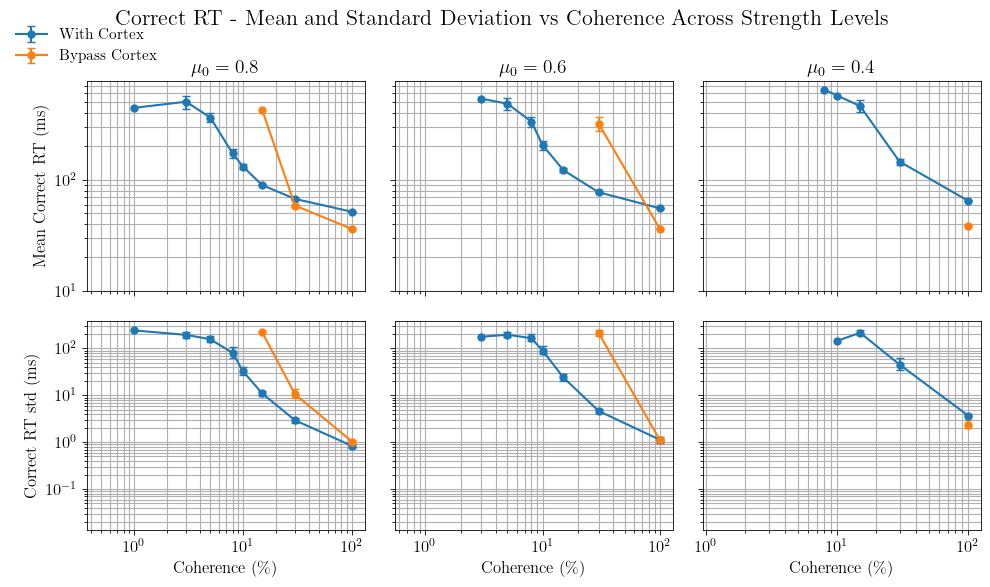

In [32]:
## ==== Get RT mean and std along with confidence intervals for each strength level ====
# --- RT Mean ---
RT_mean_08, RT_err_08 = get_CI(df_08, metric='Mean Correct RT (ms)') 
RT_mean_06, RT_err_06 = get_CI(df_06, metric='Mean Correct RT (ms)') 
RT_mean_04, RT_err_04 = get_CI(df_04, metric='Mean Correct RT (ms)') 

RT_mean_08_bypass, RT_mean_err_08_bypass = get_CI(df_08_bypass, metric='Mean Correct RT (ms)') 
RT_mean_06_bypass, RT_mean_err_06_bypass = get_CI(df_06_bypass, metric='Mean Correct RT (ms)') 
RT_mean_04_bypass, RT_mean_err_04_bypass = get_CI(df_04_bypass, metric='Mean Correct RT (ms)') 

# --- RT std ---
RT_std_08, RT_std_err_08 = get_CI(df_08, metric='Correct RT std (ms)') 
RT_std_06, RT_std_err_06 = get_CI(df_06, metric='Correct RT std (ms)') 
RT_std_04, RT_std_err_04 = get_CI(df_04, metric='Correct RT std (ms)') 

RT_std_08_bypass, RT_std_err_08_bypass = get_CI(df_08_bypass, metric='Correct RT std (ms)') 
RT_std_06_bypass, RT_std_err_06_bypass = get_CI(df_06_bypass, metric='Correct RT std (ms)') 
RT_std_04_bypass, RT_std_err_04_bypass = get_CI(df_04_bypass, metric='Correct RT std (ms)') 

coherences = summary_stats['coherence'].unique()*100

# ==== Plotting ====
fig, ax = plt.subplots(2, 3,  figsize=(10,6), subplot_kw={"xscale": "log", "yscale": "log"}, sharex = 'col', sharey = 'row')

# RT Mean
ax[0,0].errorbar(x = coherences, y = RT_mean_08, yerr = RT_err_08, fmt='o-', capsize = 3, markersize = 5, label='With Cortex')
ax[0,0].errorbar(x = coherences, y = RT_mean_08_bypass, yerr = RT_mean_err_08_bypass, fmt='o-', capsize = 3, markersize = 5, label='Bypass Cortex')
ax[0,0].set_title(f'$\mu_0 = 0.8$')
ax[0,0].set_ylabel('Mean Correct RT (ms)')
ax[0,0].grid(which = 'both')
ax[0,0].set_ylim(bottom=10)  # Set lower limit for log scale

ax[0,1].errorbar(x = coherences, y = RT_mean_06, yerr = RT_err_06, fmt='o-', capsize = 3, markersize = 5)
ax[0,1].errorbar(x = coherences, y = RT_mean_06_bypass, yerr = RT_mean_err_06_bypass, fmt='o-', capsize = 3, markersize = 5)
ax[0,1].set_title(f'$\mu_0 = 0.6$')
ax[0,1].grid(which = 'both')

ax[0,2].errorbar(x = coherences, y = RT_mean_04, yerr = RT_err_04, fmt='o-', capsize = 3, markersize = 5)
ax[0,2].errorbar(x = coherences, y = RT_mean_04_bypass, yerr = RT_mean_err_04_bypass, fmt='o-', capsize = 3, markersize = 5)
ax[0,2].set_title(f'$\mu_0 = 0.4$')
ax[0,2].grid(which = 'both')

# RT std
ax[1,0].errorbar(x = coherences, y = RT_std_08, yerr = RT_std_err_08, fmt='o-', capsize = 3, markersize = 5)
ax[1,0].errorbar(x = coherences, y = RT_std_08_bypass, yerr = RT_std_err_08_bypass, fmt='o-', capsize = 3, markersize = 5)
ax[1,0].set_xlabel('Coherence (\%)')
ax[1,0].set_ylabel('Correct RT std (ms)')
ax[1,0].grid(which = 'both')

ax[1,1].errorbar(x = coherences, y = RT_std_06, yerr = RT_std_err_06, fmt='o-', capsize = 3, markersize = 5)
ax[1,1].errorbar(x = coherences, y = RT_std_06_bypass, yerr = RT_std_err_06_bypass, fmt='o-', capsize = 3, markersize = 5)
ax[1,1].set_xlabel('Coherence (\%)')
ax[1,1].grid(which = 'both')

ax[1,2].errorbar(x = coherences, y = RT_std_04, yerr = RT_std_err_04, fmt='o-', capsize = 3, markersize = 5)
ax[1,2].errorbar(x = coherences, y = RT_std_04_bypass, yerr = RT_std_err_04_bypass, fmt='o-', capsize = 3, markersize = 5)
ax[1,2].set_xlabel('Coherence (\%)')
ax[1,2].grid(which = 'both')


fig.legend(loc="center left", bbox_to_anchor=(0.0, 0.92), frameon=False)
plt.suptitle('Correct RT - Mean and Standard Deviation vs Coherence Across Strength Levels')
plt.tight_layout()
plt.show()

# Save plot
# save_plot(fig, 'Correct RT - Mean and Standard Deviation vs Coherence', folder='../../figures/cortical dynamics/suite1', formats=('pdf', 'png'))

Yet, there is one interesting observation on the above plot: reaction times appear not to change much across strength levels. An interaction plot will therefore be created, showing how reaction time evolves across strength levels when coherence is kept fixed. Only plotting for data with the cortex.

Data for $\mu_0 = 1$ is imported from suite 1 and used in addition to the data from suite 2. Only data for $\sigma = 0.125$ is used

Loaded: ..\..\data\cortical dynamics\suite2_summary.csv
Loaded: ..\..\data\cortical dynamics\suite1_summary.csv


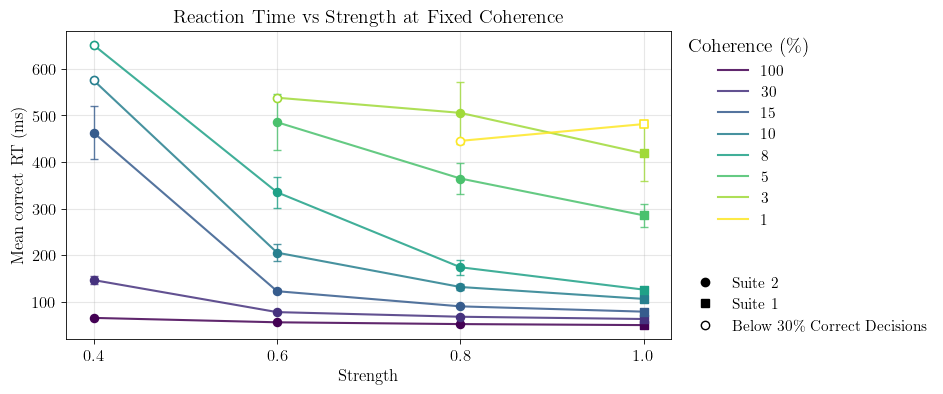

Saved: ..\..\figures\rt\RT Strength Interaction.pdf
Saved: ..\..\figures\rt\RT Strength Interaction.png


In [33]:
# ========== Making interaction plot that shows how reaction time evolves across strength levels for each coherence level ==========

# --- Load and prepare data for plotting ---
# Data from suite 2 with cortex
suite2_rt = load_results("suite2_summary.csv", "../../data/cortical dynamics").reset_index()
suite2_rt["source"] = "suite2"

# Data from suite 1 where Strength = 1, only noise_std = 0.125
suite1_rt = load_results("suite1_summary.csv", "../../data/cortical dynamics").reset_index()
suite1_rt = suite1_rt[suite1_rt["noise_std"].eq(0.125)].copy()
suite1_rt["strength"] = 1.0
suite1_rt["source"] = "suite1, $\\sigma = 0.125$"

# Concatenate into one dataframe
rt_df = pd.concat([suite2_rt, suite1_rt], ignore_index=True)

cols = [
    "coherence",
    "strength",
    "Mean Correct RT (ms)",
    "Mean Correct RT CI Margin (ms)",
    "Correct Decision (%)",
]
rt_df[cols] = rt_df[cols].apply(pd.to_numeric, errors="coerce")
rt_df = rt_df.sort_values(["coherence", "strength"])

metric = "Mean Correct RT (ms)"
err = "Mean Correct RT CI Margin (ms)"
reliable_threshold = 30 # Minimum percentage of correct decisions for reaction time data to be plotted with confidence intervals

coherences = sorted(rt_df["coherence"].dropna().unique(), reverse=True)
colors = plt.cm.viridis(np.linspace(0, 1, len(coherences)))

# ---- Plotting ----
fig, ax = plt.subplots(figsize=figure_size("single"))
for coherence, color in zip(coherences, colors):
    sub = rt_df[rt_df["coherence"].eq(coherence)].dropna(subset=[metric])
    sub = sub.sort_values("strength")

    ax.plot(
        sub["strength"],
        sub[metric],
        color=color,
        linewidth=1.5,
        alpha=0.85,
        label=f"{coherence*100:g}",
    )

    has_ci = sub[err].notna()
    ax.errorbar(
        sub.loc[has_ci, "strength"],
        sub.loc[has_ci, metric],
        yerr=sub.loc[has_ci, err],
        fmt="none",
        color=color,
        capsize=3,
        linewidth=1,
        alpha=0.8,
    )

    for source, marker in [("suite2", "o"), ("suite1, $\\sigma = 0.125$", "s")]:
        pts = sub[sub["source"].eq(source)]
        reliable = pts["Correct Decision (%)"].ge(reliable_threshold)

        ax.scatter(
            pts.loc[reliable, "strength"],
            pts.loc[reliable, metric],
            marker=marker,
            s=34,
            facecolors=color,
            edgecolors=color,
            zorder=3,
        )

        ax.scatter(
            pts.loc[~reliable, "strength"],
            pts.loc[~reliable, metric],
            marker=marker,
            s=34,
            facecolors="white",
            edgecolors=color,
            linewidths=1.2,
            zorder=4,
        )

ax.set_xlabel("Strength")
ax.set_ylabel("Mean correct RT (ms)")
ax.set_title("Reaction Time vs Strength at Fixed Coherence")
ax.set_xticks([0.4, 0.6, 0.8, 1.0])
ax.grid(True, alpha=0.3)

# Keep legends outside the plotting area so they do not overlap the lines.
coh_legend = ax.legend(
    title="Coherence (\%)",
    frameon=False,
    ncols=1,
    loc="upper left",
    bbox_to_anchor=(1.02, 1.0),
    borderaxespad=0,
)
ax.add_artist(coh_legend)

marker_legend = [
    Line2D([0], [0], marker="o", color="black", linestyle="none", label="Suite 2"),
    Line2D([0], [0], marker="s", color="black", linestyle="none", label="Suite 1"),
    Line2D(
        [0], [0],
        marker="o",
        markerfacecolor="white",
        markeredgecolor="black",
        color="black",
        linestyle="none",
        label=f"Below {reliable_threshold}\% Correct Decisions",
    ),
]
ax.legend(
    handles=marker_legend,
    frameon=False,
    loc="lower left",
    bbox_to_anchor=(1.02, 0.0),
    borderaxespad=0,
)

fig.subplots_adjust(right=0.73)
plt.show()


save_plot(fig, "RT Strength Interaction", folder="../../figures/rt", formats=("pdf", "png"))


Coherence appears to affect reaction time especially at low strength levels. Two additional trials are run at low strength level, one for high and one for low coherence.

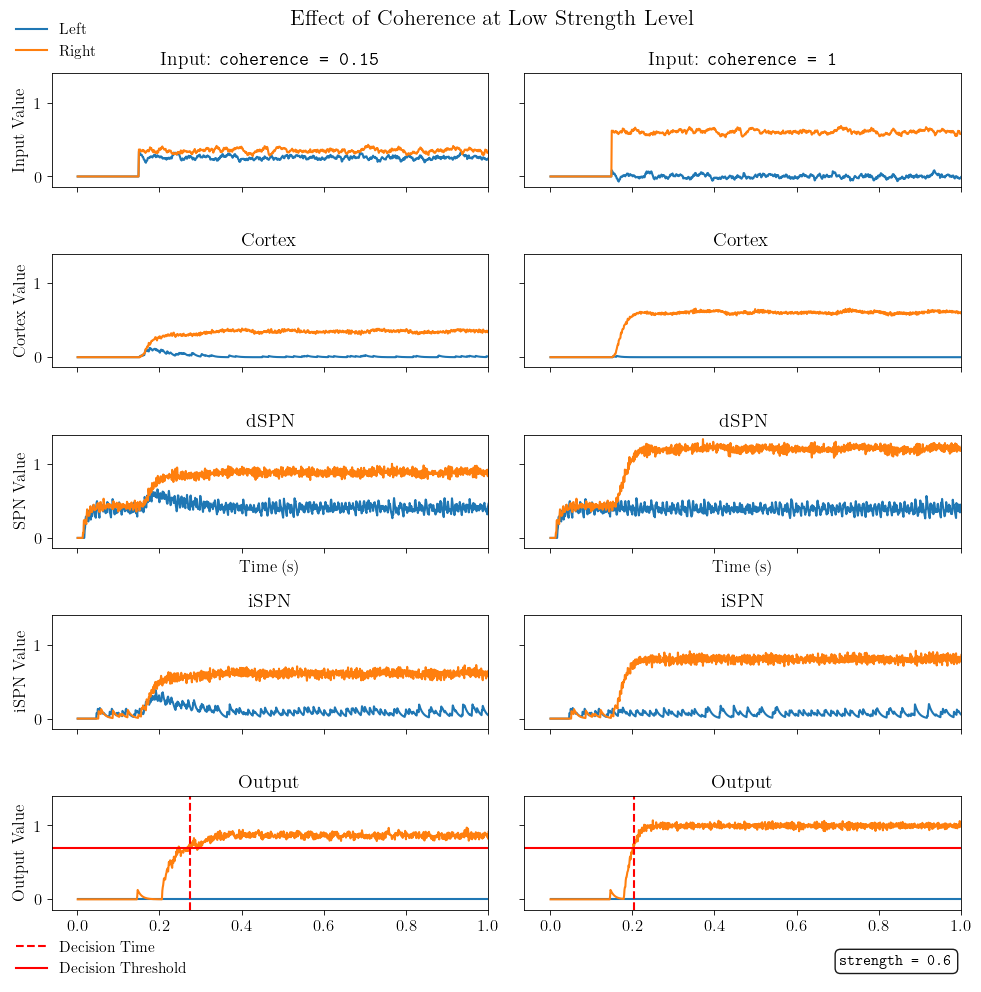

Saved: ..\..\figures\rt\Effect of Coherence at Low Strength Level.pdf
Saved: ..\..\figures\rt\Effect of Coherence at Low Strength Level.png


In [34]:
# ---- Parameters -----
task_seed = 2
t_warmup = 0.15 # Relevant when computing decision time
decision_threshold = 0.7
strength = 0.6

bg_params = BGParams()
thal_params = ThalamusParams()
cx_params = CortexParams()
model_parameters = ModelParams(
    bg_params = bg_params, 
    th_params = thal_params, 
    cx_params = cx_params
    )
trial_params = TrialParams(
    model_seed = 1, 
    task_seed = task_seed, 
    t_warmup = t_warmup, 
    decision_threshold = decision_threshold,
    decision_window= 5e-3,
    PD_window = 1,
    max_time = 1
    )
task_params_low = DotsParams(
    direction = 'right', 
    strength = strength,
    coherence = 0.15,
    noise_std = 0.125
    )
task_params_high = DotsParams(
    direction = 'right', 
    strength = strength,
    coherence = 1,
    noise_std = 0.125
    )


# ---- Run decision-making task ----

# Low coherence
task_result_low = run_task(
    model_params = model_parameters,
    dots_params = task_params_low,
    trial_params = trial_params,
    return_probes = True,

)
# High coherence
task_result_high = run_task(
    model_params = model_parameters,
    dots_params = task_params_high,
    trial_params = trial_params,
    return_probes = True,
    bypass_cortex = False
)

# ---- Get decision times ----
decision_time_low = task_result_low.decision_info['RT (ms)']/1000 + t_warmup
decision_time_high = task_result_high.decision_info['RT (ms)']/1000 + t_warmup


# ---- Extract relevant probe data ----
probes = task_result_low.probes
probes_high = task_result_high.probes


# Time
time = probes['time']
time_high = probes_high['time']

# Input probes
input_probe_low = probes['input']
input_probe_high = probes_high['input']

# Cortex probes
cortex_probe_low = probes['cortex']
cortex_probe_high = probes_high['cortex']

# SPN probes
dSPN_probe_low = probes['dSPN']
iSPN_probe_low = probes['iSPN']
dSPN_probe_high = probes_high['dSPN']
iSPN_probe_high = probes_high['iSPN']

# Output probes
output_probe_low = probes['output']
output_probe_high = probes_high['output']


# ---- Plot ----
fig, ax = plt.subplots(5, 2, figsize=figure_size('triple'), sharex = True, sharey = True)

# Low Coherence
Left, = ax[0,0].plot(time, input_probe_low[:,0], label = 'Left')
Right, = ax[0,0].plot(time, input_probe_low[:,1], label = 'Right')
ax[0,0].set_title(r'Input: \texttt{coherence = 0.15}')

ax[1,0].plot(time, cortex_probe_low[:,0])
ax[1,0].plot(time, cortex_probe_low[:,1])
ax[1,0].set_title('Cortex')

ax[2,0].plot(time, dSPN_probe_low[:,0])
ax[2,0].plot(time, dSPN_probe_low[:,1])
ax[2,0].set_title('dSPN')

ax[3,0].plot(time, iSPN_probe_low[:,0])
ax[3,0].plot(time, iSPN_probe_low[:,1])
ax[3,0].set_title('iSPN')

ax[4,0].plot(time, output_probe_low[:,0])
ax[4,0].plot(time, output_probe_low[:,1])
ax[4,0].axhline(decision_threshold, color='r', linestyle='-')
ax[4,0].set_title('Output')

# High coherence
ax[0,1].plot(time_high[:1000], input_probe_high[:,0][:1000])
ax[0,1].plot(time_high[:1000], input_probe_high[:,1][:1000])
ax[0,1].set_title(r'Input: \texttt{coherence = 1}')

ax[1,1].plot(time_high, cortex_probe_high[:,0])
ax[1,1].plot(time_high, cortex_probe_high[:,1])
ax[1,1].set_title('Cortex')

ax[2,1].plot(time_high, dSPN_probe_high[:,0])
ax[2,1].plot(time_high, dSPN_probe_high[:,1])
ax[2,1].set_title('dSPN')

ax[3,1].plot(time_high, iSPN_probe_high[:,0])
ax[3,1].plot(time_high, iSPN_probe_high[:,1])
ax[3,1].set_title('iSPN')

ax[4,1].plot(time_high, output_probe_high[:,0])
ax[4,1].plot(time_high, output_probe_high[:,1])
ax[4,1].axvline(decision_time_high, color='r', linestyle='--', label='Decision Time')
ax[4,1].set_title('Output')

# Set axes limits
ax[4,1].set_xlim(right = 1)
ax[2, 0].set_ylim(top = 1.4)

# - Set axes labels -
# x-axis
ax[2,0].set_xlabel('Time (s)')
ax[2,1].set_xlabel('Time (s)')
# y-axis
ax[0,0].set_ylabel('Input Value')
ax[1,0].set_ylabel('Cortex Value')
ax[2,0].set_ylabel('SPN Value')
ax[3,0].set_ylabel('iSPN Value')
ax[4,0].set_ylabel('Output Value')

# - Lines for decision time and threshold -
decision_line = ax[4,0].axvline(decision_time_low, color='r', linestyle='--', label='Decision Time')
threshold_line = ax[4,1].axhline(decision_threshold, color='r', linestyle='-', label='Decision Threshold')

#  - Make legends -
fig.legend(
    handles=[Left, Right],
    loc="upper left",
    bbox_to_anchor=(0.01, 0.98),
    frameon=False
)
fig.legend(
    handles=[decision_line, threshold_line],
    loc="lower left",
    bbox_to_anchor=(0.01, 0.0),
    frameon=False
)

# - Add text with task parameters -
params_text = (
    rf" \texttt{{strength = {strength}}}"
)

fig.text(
    0.96, 0.035,
    params_text,
    ha="right",
    va="top",
    usetex = True,
    fontfamily = "serif",
    fontname = "Computer Modern Roman",
    size=plt.rcParams["legend.fontsize"],
    multialignment="left",
    bbox=dict(
        boxstyle="round,pad=0.35",
        facecolor="white",
        edgecolor="0.1",
        alpha=1
    )
)

plt.suptitle('Effect of Coherence at Low Strength Level')
plt.tight_layout()
plt.subplots_adjust(bottom=0.08)
plt.show()

save_plot(fig, 'Effect of Coherence at Low Strength Level', folder='../../figures/rt', formats=('pdf', 'png'))

At a lower coherence level, there is activation of the iSPN of the non-dominat action channel. Due to lateral inhibition in the basal ganglia, this will slow down reaction time.

Although the effect of strength level on reaction time appears to be minimal for high coherence levels, it is more prominent at low coherence levels. It would also be of interest to see how changing the strength level affects the internal dynamics of the system at a constant low level of coherence

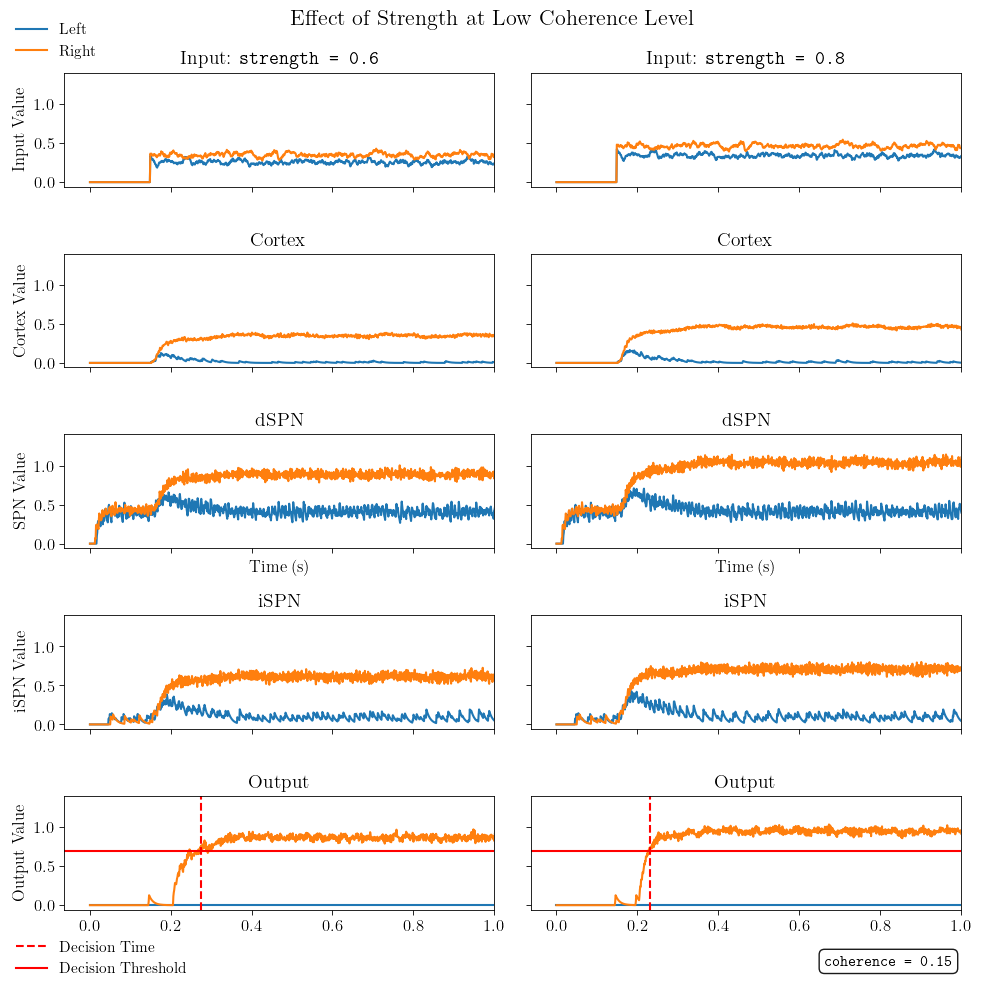

Saved: ..\..\figures\rt\Effect of Strength at Low Coherence Level.pdf
Saved: ..\..\figures\rt\Effect of Strength at Low Coherence Level.png


In [35]:
# ---- Parameters -----
task_seed = 2
t_warmup = 0.15 # Relevant when computing decision time
decision_threshold = 0.7
coherence = 0.15

bg_params = BGParams()
thal_params = ThalamusParams()
cx_params = CortexParams()
model_parameters = ModelParams(
    bg_params = bg_params, 
    th_params = thal_params, 
    cx_params = cx_params
    )
trial_params = TrialParams(
    model_seed = 1, 
    task_seed = task_seed, 
    t_warmup = t_warmup, 
    decision_threshold = decision_threshold,
    decision_window= 5e-3,
    PD_window = 1,
    max_time = 1
    )
task_params_low = DotsParams(
    direction = 'right', 
    strength = 0.6,
    coherence = coherence,
    noise_std = 0.125
    )
task_params_high = DotsParams(
    direction = 'right', 
    strength = 0.8,
    coherence = coherence,
    noise_std = 0.125
    )


# ---- Run decision-making task ----

# Low coherence
task_result_low = run_task(
    model_params = model_parameters,
    dots_params = task_params_low,
    trial_params = trial_params,
    return_probes = True,

)
# High coherence
task_result_high = run_task(
    model_params = model_parameters,
    dots_params = task_params_high,
    trial_params = trial_params,
    return_probes = True,
    bypass_cortex = False
)

# ---- Get decision times ----
decision_time_low = task_result_low.decision_info['RT (ms)']/1000 + t_warmup
decision_time_high = task_result_high.decision_info['RT (ms)']/1000 + t_warmup


# ---- Extract relevant probe data ----
probes = task_result_low.probes
probes_high = task_result_high.probes


# Time
time = probes['time']
time_high = probes_high['time']

# Input probes
input_probe_low = probes['input']
input_probe_high = probes_high['input']

# Cortex probes
cortex_probe_low = probes['cortex']
cortex_probe_high = probes_high['cortex']

# SPN probes
dSPN_probe_low = probes['dSPN']
iSPN_probe_low = probes['iSPN']
dSPN_probe_high = probes_high['dSPN']
iSPN_probe_high = probes_high['iSPN']

# Output probes
output_probe_low = probes['output']
output_probe_high = probes_high['output']


# ---- Plot ----
fig, ax = plt.subplots(5, 2, figsize=figure_size('triple'), sharex = True, sharey = True)

# Low Strength
Left, = ax[0,0].plot(time, input_probe_low[:,0], label = 'Left')
Right, = ax[0,0].plot(time, input_probe_low[:,1], label = 'Right')
ax[0,0].set_title(r'Input: \texttt{strength = 0.6}')

ax[1,0].plot(time, cortex_probe_low[:,0])
ax[1,0].plot(time, cortex_probe_low[:,1])
ax[1,0].set_title('Cortex')

ax[2,0].plot(time, dSPN_probe_low[:,0])
ax[2,0].plot(time, dSPN_probe_low[:,1])
ax[2,0].set_title('dSPN')

ax[3,0].plot(time, iSPN_probe_low[:,0])
ax[3,0].plot(time, iSPN_probe_low[:,1])
ax[3,0].set_title('iSPN')

ax[4,0].plot(time, output_probe_low[:,0])
ax[4,0].plot(time, output_probe_low[:,1])
ax[4,0].axhline(decision_threshold, color='r', linestyle='-')
ax[4,0].set_title('Output')

# High Strength
ax[0,1].plot(time_high[:1000], input_probe_high[:,0][:1000])
ax[0,1].plot(time_high[:1000], input_probe_high[:,1][:1000])
ax[0,1].set_title(r'Input: \texttt{strength = 0.8}')

ax[1,1].plot(time_high, cortex_probe_high[:,0])
ax[1,1].plot(time_high, cortex_probe_high[:,1])
ax[1,1].set_title('Cortex')

ax[2,1].plot(time_high, dSPN_probe_high[:,0])
ax[2,1].plot(time_high, dSPN_probe_high[:,1])
ax[2,1].set_title('dSPN')

ax[3,1].plot(time_high, iSPN_probe_high[:,0])
ax[3,1].plot(time_high, iSPN_probe_high[:,1])
ax[3,1].set_title('iSPN')

ax[4,1].plot(time_high, output_probe_high[:,0])
ax[4,1].plot(time_high, output_probe_high[:,1])
ax[4,1].axvline(decision_time_high, color='r', linestyle='--', label='Decision Time')
ax[4,1].set_title('Output')

# Set axes limits
ax[4,1].set_xlim(right = 1)
ax[2, 0].set_ylim(top = 1.4)

# - Set axes labels -
# x-axis
ax[2,0].set_xlabel('Time (s)')
ax[2,1].set_xlabel('Time (s)')
# y-axis
ax[0,0].set_ylabel('Input Value')
ax[1,0].set_ylabel('Cortex Value')
ax[2,0].set_ylabel('SPN Value')
ax[3,0].set_ylabel('iSPN Value')
ax[4,0].set_ylabel('Output Value')

# - Lines for decision time and threshold -
decision_line = ax[4,0].axvline(decision_time_low, color='r', linestyle='--', label='Decision Time')
threshold_line = ax[4,1].axhline(decision_threshold, color='r', linestyle='-', label='Decision Threshold')

#  - Make legends -
fig.legend(
    handles=[Left, Right],
    loc="upper left",
    bbox_to_anchor=(0.01, 0.98),
    frameon=False
)
fig.legend(
    handles=[decision_line, threshold_line],
    loc="lower left",
    bbox_to_anchor=(0.01, 0.0),
    frameon=False
)

# - Add text with task parameters -
params_text = (
    rf" \texttt{{coherence = {coherence}}}"
)

fig.text(
    0.96, 0.035,
    params_text,
    ha="right",
    va="top",
    usetex = True,
    fontfamily = "serif",
    fontname = "Computer Modern Roman",
    size=plt.rcParams["legend.fontsize"],
    multialignment="left",
    bbox=dict(
        boxstyle="round,pad=0.35",
        facecolor="white",
        edgecolor="0.1",
        alpha=1
    )
)

plt.suptitle('Effect of Strength at Low Coherence Level')
plt.tight_layout()
plt.subplots_adjust(bottom=0.08)
plt.show()

save_plot(fig, 'Effect of Strength at Low Coherence Level', folder='../../figures/rt', formats=('pdf', 'png'))

It is apparent that the system reacts slower at a lower level of strength, it is not, however, immediately obvious why this is the case. The dynamics at both strength levels seem similar. The dSPN sees a higher activation at a high strenght level, but so does the iSPN. I lack an explanation for this phenomenon